# PIPELINE DE LIMPIEZA DE DATOS

Cargar librerías:

In [36]:
from google.colab import drive
from sklearn.linear_model import LinearRegression
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

# Proceso ETL - Extract, transform and load the data

# 1. Importar datos (Extract the data)

In [2]:
# 1. Montar Google Drive
drive.mount('/content/drive')

# 2. Definir la ruta del archivo en drive
ruta_archivo = '/content/drive/MyDrive/6to_semestre/Datos.csv'

# 3. Leer los datos
if os.path.exists(ruta_archivo):
    df = pd.read_csv(ruta_archivo)
    print("Archivo cargado exitosamente:")
    print(df.head())
else:
    print(f"No se encontró el archivo en la ruta: {ruta_archivo}")

Mounted at /content/drive
Archivo cargado exitosamente:
    Año  Cantón Provincia  Empleo total registrado  \
0  2019  Ibarra  Imbabura              36354.83333   
1  2020  Ibarra  Imbabura              33938.58333   
2  2021  Ibarra  Imbabura              33788.50000   
3  2022  Ibarra  Imbabura              35072.00000   
4  2023  Ibarra  Imbabura              35493.83333   

   Empleo masculino registrado  Empleo femenino registrado  \
0                  20509.66667                 15845.16667   
1                  19023.08333                 14915.50000   
2                  18646.50000                 15142.00000   
3                  19398.83333                 15673.16667   
4                  19467.16667                 16026.66667   

   Salario promedio total registrado  \
0                         681.037298   
1                         680.388767   
2                         695.749373   
3                         712.406398   
4                         745.633942   

   Sa

In [3]:
df.head()

,Año,Cantón,Provincia,Empleo total registrado,Empleo masculino registrado,Empleo femenino registrado,Salario promedio total registrado,Salario mensual promedio masculino registrado,Salario mensual promedio femenino registrado,Ventas locales,Recaudación tributaria,Valor agregado bruto de producción,Población,Número de nuevas compañías,Valor agregado bruto de producción per cápita,variación interanual de la producción per cápita,variación interanual real de la producción per cápita
0,2019,Ibarra,Imbabura,36354.83333,20509.66667,15845.16667,681.037298,668.718725,697.001612,1.306461e+09,55595874.88,846082930.0,216440.0,102.0,3909.087646,-1.313180,-1.579596
1,2020,Ibarra,Imbabura,33938.58333,19023.08333,14915.50000,680.388767,661.010625,705.071864,1.008828e+09,48235019.51,708985360.0,219063.0,102.0,3236.445041,-17.207151,-16.868552
2,2021,Ibarra,Imbabura,33788.50000,18646.50000,15142.00000,695.749373,677.790268,717.855525,1.231320e+09,57090619.35,730790540.0,221282.0,196.0,3302.530436,2.041913,1.900482
3,2022,Ibarra,Imbabura,35072.00000,19398.83333,15673.16667,712.406398,693.875086,735.384135,1.367972e+09,69732403.50,840817470.0,223545.0,211.0,3761.289539,13.891139,10.427318
4,2023,Ibarra,Imbabura,35493.83333,19467.16667,16026.66667,745.633942,725.726568,769.907537,1.462298e+09,70317766.83,925940000.0,225970.0,211.0,4097.623578,8.941987,6.721817


# 2. Transform the data

En este paso llevaremos a cabo el EDA (Exploratory Data Analysis para asegurar la limpieza y claidad de los datos)

## 1. Data Overview:

In [4]:
print("Las columnas con sus respectivos tipo de datos son: ")
df.info()

Las columnas con sus respectivos tipo de datos son: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1334 entries, 0 to 1333
Data columns (total 17 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Año                                                    1334 non-null   int64  
 1   Cantón                                                 1334 non-null   object 
 2   Provincia                                              1334 non-null   object 
 3   Empleo total registrado                                1334 non-null   float64
 4   Empleo masculino registrado                            1334 non-null   float64
 5   Empleo femenino registrado                             1334 non-null   float64
 6   Salario promedio total registrado                      1334 non-null   float64
 7   Salario mensual promedio masculino registrado          1334 non-null   float64


In [5]:
# 1. Definir las columnas a utilizar
cols_interes = [
    'Año', 'Cantón', 'Provincia',
    'Empleo total registrado',
    'Salario promedio total registrado', 'Ventas locales', 'Recaudación tributaria',
    'Población', 'Número de nuevas compañías',
    'Valor agregado bruto de producción per cápita',
    'variación interanual real de la producción per cápita'
]

# 2. Filtrar el DataFrame original
df_limpio = df[cols_interes].copy()

In [6]:
print("Las dimensiones del dataset usado son: ")
df_limpio.shape

Las dimensiones del dataset usado son: 


(1334, 11)

## 2. Revisión de NA

In [7]:
# Cuenta los nulos por columna
nulos_por_columna = df_limpio.isnull().sum()

# Muestra el resultado
print(nulos_por_columna)

Año                                                        0
Cantón                                                     0
Provincia                                                  0
Empleo total registrado                                    0
Salario promedio total registrado                          0
Ventas locales                                             8
Recaudación tributaria                                     8
Población                                                229
Número de nuevas compañías                                 8
Valor agregado bruto de producción per cápita            229
variación interanual real de la producción per cápita    229
dtype: int64


**Revisión de NA por cada variable:**

#### 1. Recaudación tributaria, Ventas locales y Número de nuevas compañías

In [8]:
# 1. Filtramos las filas donde la columna específica tiene nulos
df_nulos = df_limpio[df_limpio['Recaudación tributaria'].isnull()]

# 2. Agrupamos por 'Cantón' y 'Año' y contamos
conteo_nulos = df_nulos.groupby(['Cantón', 'Año']).size().reset_index(name='cantidad_nulos')

# 3. Mostrar el resultado
print(conteo_nulos)

           Cantón   Año  cantidad_nulos
0     El Piedrero  2019               1
1     El Piedrero  2020               1
2     El Piedrero  2021               1
3     El Piedrero  2022               1
4  Manga del Cura  2019               1
5  Manga del Cura  2020               1
6  Manga del Cura  2021               1
7  Manga del Cura  2022               1


In [9]:
# 1. Filtramos las filas donde la columna específica tiene nulos
df_nulos = df_limpio[df_limpio['Ventas locales'].isnull()]

# 2. Agrupamos por 'Cantón' y 'Año' y contamos
conteo_nulos = df_nulos.groupby(['Cantón', 'Año']).size().reset_index(name='cantidad_nulos')

# 3. Mostrar el resultado
print(conteo_nulos)

           Cantón   Año  cantidad_nulos
0     El Piedrero  2019               1
1     El Piedrero  2020               1
2     El Piedrero  2021               1
3     El Piedrero  2022               1
4  Manga del Cura  2019               1
5  Manga del Cura  2020               1
6  Manga del Cura  2021               1
7  Manga del Cura  2022               1


In [10]:
# 1. Filtramos las filas donde la columna específica tiene nulos
df_nulos = df_limpio[df_limpio['Número de nuevas compañías'].isnull()]

# 2. Agrupamos por 'Cantón' y 'Año' y contamos
conteo_nulos = df_nulos.groupby(['Cantón', 'Año']).size().reset_index(name='cantidad_nulos')

# 3. Mostrar el resultado
print(conteo_nulos)

           Cantón   Año  cantidad_nulos
0     El Piedrero  2019               1
1     El Piedrero  2020               1
2     El Piedrero  2021               1
3     El Piedrero  2022               1
4  Manga del Cura  2019               1
5  Manga del Cura  2020               1
6  Manga del Cura  2021               1
7  Manga del Cura  2022               1


Se ha determinado la eliminación de los registros correspondientes a los cantones **El Piedrero y La Manga del Cur**a del dataset de entrenamiento. Esta decisión se fundamenta en los siguientes criterios técnicos:

**Heterogeneidad Administrativa:** Dichas zonas fueron históricamente territorios en disputa y no cuentan con la estructura administrativa de un GAD Municipal (Gobierno Autónomo Descentralizado). En consecuencia, las variables económicas críticas como Recaudación tributaria o Número de nuevas compañías presentan valores nulos estructurales, no aleatorios.

**Prevención de Sesgos de Imputación:** La imputación de datos económicos para estas zonas mediante promedios provinciales introduciría un "ruido" sistemático. Al ser territorios sin recaudación tributaria formal ni registros mercantiles, asignarles valores promedio de cantones formalmente establecidos sesgaría el modelo, induciendo predicciones de riesgo de pobreza artificialmente distorsionadas.

**Integridad de la Muestra:** Dado que estos registros representan menos del 1% del volumen total de datos, su exclusión mejora la robustez del modelo y asegura que la clasificación de riesgo de pobreza se realice sobre una base de comparabilidad institucional equitativa (cantones con competencias municipales plenas).

In [11]:
# 1. Definir la lista de exclusión
zonas_no_delimitadas = ['El Piedrero', 'Manga del Cura']

# 2. Filtrar el DataFrame principal de manera permanente
df_limpio = df_limpio[~df_limpio['Cantón'].isin(zonas_no_delimitadas)].copy()

# 3. Eliminar explícitamente cualquier registro residual de esos cantones si existieran en otros DataFrames
if 'df_proyeccion' in locals():
    df_proyeccion = df_proyeccion[~df_proyeccion['Cantón'].isin(zonas_no_delimitadas)].copy()

cantones_reales = df_limpio['Cantón'].unique()
verificacion = [c for c in zonas_no_delimitadas if c in cantones_reales]

if not verificacion:
    print("Los cantones han sido eliminados totalmente del dataset.")
    print(f"Nueva forma del dataset: {df_limpio.shape}")
else:
    print(f"Error: Aún se detectaron los siguientes cantones: {verificacion}")

Los cantones han sido eliminados totalmente del dataset.
Nueva forma del dataset: (1326, 11)


#### 2. Población

In [12]:
# 1. Filtramos las filas donde la columna específica tiene nulos
df_nulos = df_limpio[df_limpio['Población'].isnull()]

# 2. Agrupamos por 'Cantón' y 'Año' y contamos
conteo_nulos = df_nulos.groupby(['Cantón', 'Año']).size().reset_index(name='cantidad_nulos')

# 3. Mostrar el resultado
print(conteo_nulos)

                               Cantón   Año  cantidad_nulos
0                          24 De Mayo  2024               1
1                            Aguarico  2024               1
2                              Alausí  2024               1
3    Alfredo Baquerizo Moreno (Juján)  2024               1
4                              Ambato  2024               1
..                                ...   ...             ...
215                          Yacuambi  2024               1
216                          Yantzaza  2024               1
217                            Zamora  2024               1
218                         Zapotillo  2024               1
219                            Zaruma  2024               1

[220 rows x 3 columns]


In [13]:
# 1. Crear las filas para 2024 (si no existen)
cantones = df_limpio['Cantón'].unique()
for canton in cantones:
    # Verificamos si la fila de 2024 ya existe para este cantón
    if not ((df_limpio['Cantón'] == canton) & (df_limpio['Año'] == 2024)).any():
        # Creamos una fila nueva con valores NaN para el 2024
        nueva_fila = pd.DataFrame({'Cantón': [canton], 'Año': [2024]})
        df_limpio = pd.concat([df_limpio, nueva_fila], ignore_index=True)

# 2. Ahora sí, calculamos la proyección e imputamos solo el valor en la fila de 2024
for canton in cantones:
    df_canton = df_limpio[(df_limpio['Cantón'] == canton) & (df_limpio['Año'] != 2024)].dropna(subset=['Población'])

    if len(df_canton) >= 2:
        X = df_canton[['Año']]
        y = df_canton['Población']

        model = LinearRegression()
        model.fit(X, y)

        pob_2024 = model.predict([[2024]])[0]

        # Imputamos directamente en el df_limpio
        mask = (df_limpio['Cantón'] == canton) & (df_limpio['Año'] == 2024)
        df_limpio.loc[mask, 'Población'] = int(pob_2024)

print("Proyección imputada exitosamente en el DataFrame original.")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/

Proyección imputada exitosamente en el DataFrame original.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/

In [14]:
# Ver las últimas 10 filas del dataset
print(df_limpio.tail(10))

       Año                     Cantón Provincia  Empleo total registrado  \
1324  2021  General Antonio Elizalde     Guayas               969.583333   
1325  2022  General Antonio Elizalde     Guayas              1078.333333   
1326  2023  General Antonio Elizalde     Guayas              1075.000000   
1327  2024  General Antonio Elizalde     Guayas              1045.000000   
1328  2019               Isidro Ayora    Guayas              1407.750000   
1329  2020               Isidro Ayora    Guayas              1482.750000   
1330  2021               Isidro Ayora    Guayas              1617.333333   
1331  2022               Isidro Ayora    Guayas              1758.583333   
1332  2023               Isidro Ayora    Guayas              1893.083333   
1333  2024               Isidro Ayora    Guayas              2179.250000   

      Salario promedio total registrado  Ventas locales  \
1324                         518.868242    5.747295e+07   
1325                         527.764867    5.

##### 3. Valor agregado bruto de producción per cápita            

In [15]:
# 1. Filtramos las filas donde la columna específica tiene nulos
df_nulos = df_limpio[df_limpio['Valor agregado bruto de producción per cápita'].isnull()]

# 2. Agrupamos por 'Cantón' y 'Año' y contamos
conteo_nulos = df_nulos.groupby(['Cantón', 'Año']).size().reset_index(name='cantidad_nulos')

# 3. Mostrar el resultado
print(conteo_nulos)

                               Cantón   Año  cantidad_nulos
0                          24 De Mayo  2024               1
1                            Aguarico  2024               1
2                              Alausí  2024               1
3    Alfredo Baquerizo Moreno (Juján)  2024               1
4                              Ambato  2024               1
..                                ...   ...             ...
215                          Yacuambi  2024               1
216                          Yantzaza  2024               1
217                            Zamora  2024               1
218                         Zapotillo  2024               1
219                            Zaruma  2024               1

[220 rows x 3 columns]


In [16]:
# 1. Crear las filas para 2024 (si no existen)
cantones = df_limpio['Cantón'].unique()
for canton in cantones:
    # Verificamos si la fila de 2024 ya existe para este cantón
    if not ((df_limpio['Cantón'] == canton) & (df_limpio['Año'] == 2024)).any():
        # Creamos una fila nueva con valores NaN para el 2024
        nueva_fila = pd.DataFrame({'Cantón': [canton], 'Año': [2024]})
        df_limpio = pd.concat([df_limpio, nueva_fila], ignore_index=True)

# 2. Ahora sí, calculamos la proyección e imputamos solo el valor en la fila de 2024
for canton in cantones:
    df_canton = df_limpio[(df_limpio['Cantón'] == canton) & (df_limpio['Año'] != 2024)].dropna(subset=['Valor agregado bruto de producción per cápita'])

    if len(df_canton) >= 2:
        X = df_canton[['Año']]
        y = df_canton[['Valor agregado bruto de producción per cápita']]

        model = LinearRegression()
        model.fit(X, y)

        pob_2024 = model.predict([[2024]])[0]

        # Imputamos directamente en el df_limpio
        mask = (df_limpio['Cantón'] == canton) & (df_limpio['Año'] == 2024)
        df_limpio.loc[mask, 'Valor agregado bruto de producción per cápita'] = int(pob_2024)

print("Proyección imputada exitosamente en el DataFrame original.")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/tmp/ipykernel_781/2850974798.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  df_limpio.loc[mask, 'Valor agregado bruto de producción per cápita'] = int(pob_2024)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/tmp/ipykernel_781/2850974798.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  df_limpio.l

Proyección imputada exitosamente en el DataFrame original.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/tmp/ipykernel_781/2850974798.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  df_limpio.loc[mask, 'Valor agregado bruto de producción per cápita'] = int(pob_2024)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/tmp/ipykernel_781/2850974798.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  df_limpio.l

In [17]:
# Ver las últimas 10 filas del dataset
print(df_limpio.tail(10))

       Año                     Cantón Provincia  Empleo total registrado  \
1324  2021  General Antonio Elizalde     Guayas               969.583333   
1325  2022  General Antonio Elizalde     Guayas              1078.333333   
1326  2023  General Antonio Elizalde     Guayas              1075.000000   
1327  2024  General Antonio Elizalde     Guayas              1045.000000   
1328  2019               Isidro Ayora    Guayas              1407.750000   
1329  2020               Isidro Ayora    Guayas              1482.750000   
1330  2021               Isidro Ayora    Guayas              1617.333333   
1331  2022               Isidro Ayora    Guayas              1758.583333   
1332  2023               Isidro Ayora    Guayas              1893.083333   
1333  2024               Isidro Ayora    Guayas              2179.250000   

      Salario promedio total registrado  Ventas locales  \
1324                         518.868242    5.747295e+07   
1325                         527.764867    5.

##### 4. Variación interanual real de la producción per cápita

In [18]:
# 1. Filtramos las filas donde la columna específica tiene nulos
df_nulos = df_limpio[df_limpio['variación interanual real de la producción per cápita'].isnull()]

# 2. Agrupamos por 'Cantón' y 'Año' y contamos
conteo_nulos = df_nulos.groupby(['Cantón', 'Año']).size().reset_index(name='cantidad_nulos')

# 3. Mostrar el resultado
print(conteo_nulos)

                               Cantón   Año  cantidad_nulos
0                          24 De Mayo  2024               1
1                            Aguarico  2024               1
2                              Alausí  2024               1
3    Alfredo Baquerizo Moreno (Juján)  2024               1
4                              Ambato  2024               1
..                                ...   ...             ...
215                          Yacuambi  2024               1
216                          Yantzaza  2024               1
217                            Zamora  2024               1
218                         Zapotillo  2024               1
219                            Zaruma  2024               1

[220 rows x 3 columns]


In [19]:
# 1. Crear las filas para 2024 (si no existen)
cantones = df_limpio['Cantón'].unique()
for canton in cantones:
    # Verificamos si la fila de 2024 ya existe para este cantón
    if not ((df_limpio['Cantón'] == canton) & (df_limpio['Año'] == 2024)).any():
        # Creamos una fila nueva con valores NaN para el 2024
        nueva_fila = pd.DataFrame({'Cantón': [canton], 'Año': [2024]})
        df_limpio = pd.concat([df_limpio, nueva_fila], ignore_index=True)

# 2. Ahora sí, calculamos la proyección e imputamos solo el valor en la fila de 2024
for canton in cantones:
    df_canton = df_limpio[(df_limpio['Cantón'] == canton) & (df_limpio['Año'] != 2024)].dropna(subset=['Valor agregado bruto de producción per cápita'])

    if len(df_canton) >= 2:
        X = df_canton[['Año']]
        y = df_canton[['variación interanual real de la producción per cápita']]

        model = LinearRegression()
        model.fit(X, y)

        pob_2024 = model.predict([[2024]])[0]

        # Imputamos directamente en el df_limpio
        mask = (df_limpio['Cantón'] == canton) & (df_limpio['Año'] == 2024)
        df_limpio.loc[mask, 'variación interanual real de la producción per cápita'] = int(pob_2024)

print("Proyección imputada exitosamente en el DataFrame original.")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/tmp/ipykernel_781/1854025513.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  df_limpio.loc[mask, 'variación interanual real de la producción per cápita'] = int(pob_2024)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/tmp/ipykernel_781/1854025513.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  df_

Proyección imputada exitosamente en el DataFrame original.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/tmp/ipykernel_781/1854025513.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  df_limpio.loc[mask, 'variación interanual real de la producción per cápita'] = int(pob_2024)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/tmp/ipykernel_781/1854025513.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  df_

Se comprueba que la base esta libre de nulos

In [20]:
df_limpio.isnull().sum()

,0
Año,0
Cantón,0
Provincia,0
Empleo total registrado,0
Salario promedio total registrado,0
Ventas locales,0
Recaudación tributaria,0
Población,0
Número de nuevas compañías,0
Valor agregado bruto de producción per cápita,0


## 3. Revisión de formatos

In [21]:
for columna in df_limpio.columns:
    print("\n____________________________________________________________________________")
    print(f"Valores únicos en: {columna} ---")

    num_unicos = df_limpio[columna].unique()
    print(f"Valores únicos: {num_unicos}")


____________________________________________________________________________
Valores únicos en: Año ---
Valores únicos: [2019 2020 2021 2022 2023 2024]

____________________________________________________________________________
Valores únicos en: Cantón ---
Valores únicos: ['Ibarra' 'Antonio Ante' 'Cotacachi' 'Otavalo' 'Pimampiro'
 'San Miguel De Urcuquí' 'Cuenca' 'Girón' 'Gualaceo' 'Nabón' 'Paute'
 'Pucará' 'San Fernando' 'Santa Isabel' 'Sígsig' 'Oña' 'Loja ' 'Calvas '
 'Catamayo ' 'Celica ' 'Chaguarpamba ' 'Espíndola ' 'Gonzanamá ' 'Macará '
 'Paltas' 'Chordeleg' 'Puyango' 'Saraguro' 'Sozoranga' 'Zapotillo'
 'Pindal' 'Quilanga' 'Olmedo' 'El Pan' 'Sevilla De Oro' 'Guachapala'
 'Camilo Ponce Enríquez' 'Babahoyo ' 'Baba ' 'Montalvo ' 'Puebloviejo'
 'Quevedo ' 'Urdaneta' 'Ventanas' 'Vinces' 'Palenque' 'Buena Fe'
 'Valencia' 'Mocache' 'Quinsaloma' 'Portoviejo ' 'Bolívar ' 'Chone '
 'El Carmen ' 'Flavio Alfaro ' 'Jipijapa ' 'Junín ' 'Manta '
 'Montecristi ' 'Paján ' 'Pichincha ' 'Rocafu

Realizamos un strip para evitar vacios antes y después de cada palabra

In [22]:
# 1. Identificamos solo las columnas que son de tipo objeto
cols_texto = df_limpio.select_dtypes(include=['object']).columns

# 2. Aplicamos el strip a cada una de esas columnas
for col in cols_texto:
    df_limpio[col] = df_limpio[col].str.strip()
df_limpio.head()

,Año,Cantón,Provincia,Empleo total registrado,Salario promedio total registrado,Ventas locales,Recaudación tributaria,Población,Número de nuevas compañías,Valor agregado bruto de producción per cápita,variación interanual real de la producción per cápita
0,2019,Ibarra,Imbabura,36354.83333,681.037298,1.306461e+09,55595874.88,216440.0,102.0,3909.087646,-1.579596
1,2020,Ibarra,Imbabura,33938.58333,680.388767,1.008828e+09,48235019.51,219063.0,102.0,3236.445041,-16.868552
2,2021,Ibarra,Imbabura,33788.50000,695.749373,1.231320e+09,57090619.35,221282.0,196.0,3302.530436,1.900482
3,2022,Ibarra,Imbabura,35072.00000,712.406398,1.367972e+09,69732403.50,223545.0,211.0,3761.289539,10.427318
4,2023,Ibarra,Imbabura,35493.83333,745.633942,1.462298e+09,70317766.83,225970.0,211.0,4097.623578,6.721817


Realizamos un redondeo para limpiar el formato de los datos numéricos

In [23]:
# 1. Identificamos columnas numéricas con decimales (float64)
cols_float = df_limpio.select_dtypes(include=['float64']).columns

# 2. Aplicamos el redondeo a 2 decimales
df_limpio[cols_float] = df_limpio[cols_float].round(2)

df_limpio.head()

,Año,Cantón,Provincia,Empleo total registrado,Salario promedio total registrado,Ventas locales,Recaudación tributaria,Población,Número de nuevas compañías,Valor agregado bruto de producción per cápita,variación interanual real de la producción per cápita
0,2019,Ibarra,Imbabura,36354.83,681.04,1.306461e+09,55595874.88,216440.0,102.0,3909.09,-1.58
1,2020,Ibarra,Imbabura,33938.58,680.39,1.008828e+09,48235019.51,219063.0,102.0,3236.45,-16.87
2,2021,Ibarra,Imbabura,33788.50,695.75,1.231320e+09,57090619.35,221282.0,196.0,3302.53,1.90
3,2022,Ibarra,Imbabura,35072.00,712.41,1.367972e+09,69732403.50,223545.0,211.0,3761.29,10.43
4,2023,Ibarra,Imbabura,35493.83,745.63,1.462298e+09,70317766.83,225970.0,211.0,4097.62,6.72


## 3. Analítica descriptiva

Realizamos la estadística descriptiva de las variables numéricas

In [24]:
df_limpio[cols_float].describe()

,Empleo total registrado,Salario promedio total registrado,Ventas locales,Recaudación tributaria,Población,Número de nuevas compañías,Valor agregado bruto de producción per cápita,variación interanual real de la producción per cápita
count,1326.000000,1326.000000,1.326000e+03,1.326000e+03,1.326000e+03,1326.000000,1326.000000,1326.000000
mean,12524.511750,696.587647,9.544625e+08,7.189415e+07,7.994024e+04,73.504525,4785.160830,3.260166
std,70093.679715,124.253940,6.440871e+09,6.014075e+08,2.765089e+05,468.247422,11071.155445,32.023949
min,93.830000,441.730000,6.004236e+05,6.436302e+04,2.193000e+03,0.000000,766.820000,-62.720000
25%,706.562500,613.147500,2.097496e+07,7.658832e+05,1.259275e+04,4.000000,1788.320000,-5.000000
50%,1528.085000,690.075000,6.632157e+07,1.815664e+06,2.702500e+04,8.000000,2467.320000,2.670000
75%,4946.230000,766.672500,2.426029e+08,8.099512e+06,6.256175e+04,22.000000,3754.462500,9.000000
max,884817.830000,1480.800000,8.570419e+10,9.768836e+09,2.952313e+06,6451.000000,175143.010000,1017.810000


In [25]:
# Iteramos sobre las columnas que contienen texto
for col in cols_texto:
    print(f"--- Frecuencia para la variable: {col} ---")

    # Calculamos frecuencia absoluta (conteo) y porcentual (normalize=True)
    frec_absoluta = df_limpio[col].value_counts()
    frec_porcentual = df_limpio[col].value_counts(normalize=True) * 100

    # Combinamos ambas en un solo DataFrame para una lectura fácil
    df_frecuencias = pd.DataFrame({
        'Absoluta': frec_absoluta,
        'Porcentual (%)': frec_porcentual.round(2)
    })

    print(df_frecuencias)
    print("\n" + "="*40 + "\n")

--- Frecuencia para la variable: Cantón ---
                             Absoluta  Porcentual (%)
Cantón                                               
Olmedo                             12            0.90
Bolívar                            12            0.90
Ibarra                              6            0.45
Otavalo                             6            0.45
Pimampiro                           6            0.45
...                               ...             ...
Coronel Marcelino Maridueña         6            0.45
Lomas De Sargentillo                6            0.45
Nobol                               6            0.45
General Antonio Elizalde            6            0.45
Isidro Ayora                        6            0.45

[219 rows x 2 columns]


--- Frecuencia para la variable: Provincia ---
                                Absoluta  Porcentual (%)
Provincia                                               
Guayas                               150           11.31
Manabí    

## 4. Graficos univariados

--- Análisis Estadístico: Empleo total registrado ---
Q1: 706.56 | Mediana: 1528.09 | Q3: 4946.23
Media: 12524.51
Outliers detectados: 159 (11.99% del total)
----------------------------------------


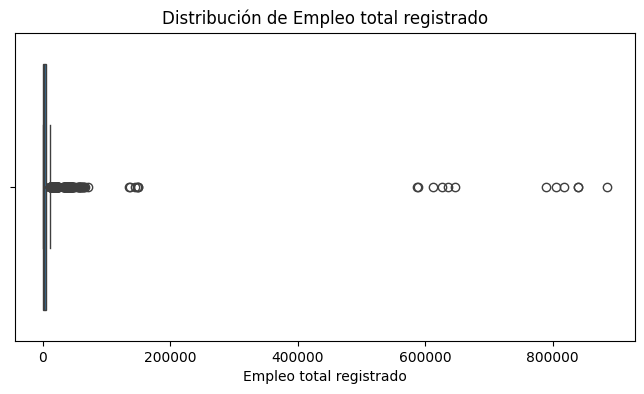

--- Análisis Estadístico: Salario promedio total registrado ---
Q1: 613.15 | Mediana: 690.08 | Q3: 766.67
Media: 696.59
Outliers detectados: 24 (1.81% del total)
----------------------------------------


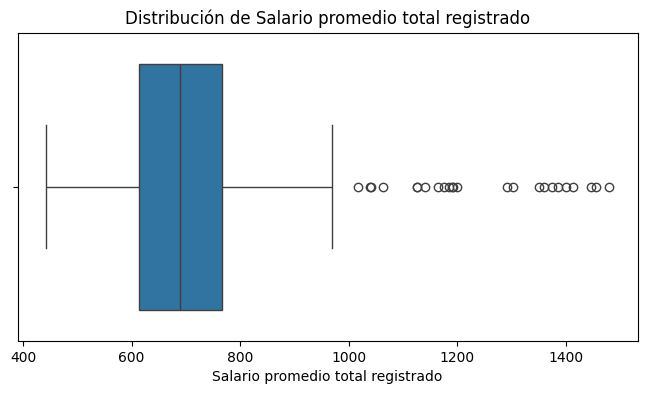

--- Análisis Estadístico: Ventas locales ---
Q1: 20974957.56 | Mediana: 66321572.35 | Q3: 242602949.28
Media: 954462524.22
Outliers detectados: 174 (13.12% del total)
----------------------------------------


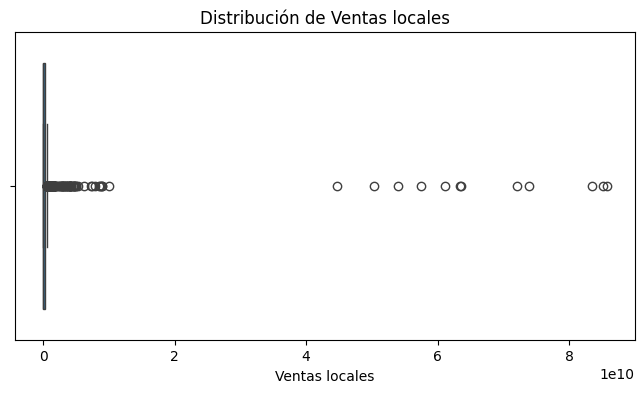

--- Análisis Estadístico: Recaudación tributaria ---
Q1: 765883.16 | Mediana: 1815663.52 | Q3: 8099512.47
Media: 71894150.40
Outliers detectados: 189 (14.25% del total)
----------------------------------------


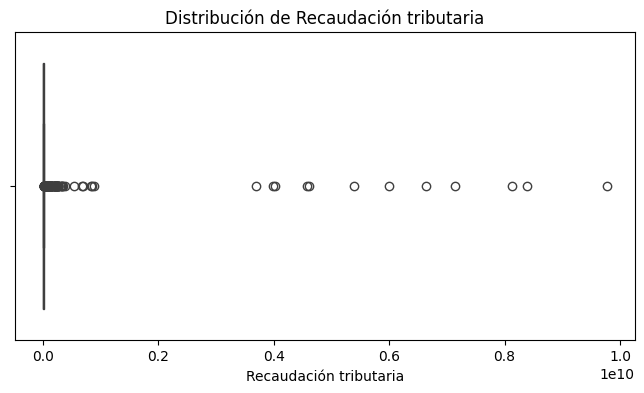

--- Análisis Estadístico: Población ---
Q1: 12592.75 | Mediana: 27025.00 | Q3: 62561.75
Media: 79940.24
Outliers detectados: 115 (8.67% del total)
----------------------------------------


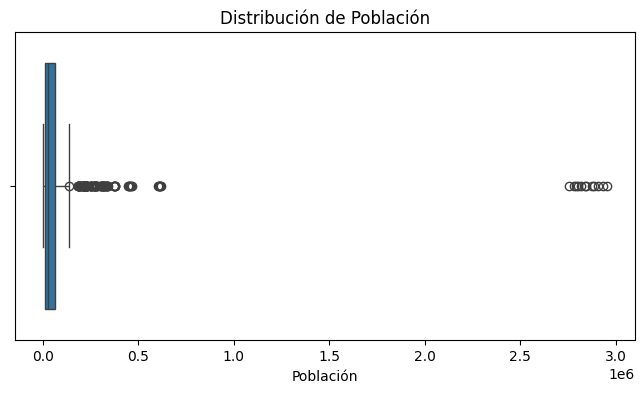

--- Análisis Estadístico: Número de nuevas compañías ---
Q1: 4.00 | Mediana: 8.00 | Q3: 22.00
Media: 73.50
Outliers detectados: 163 (12.29% del total)
----------------------------------------


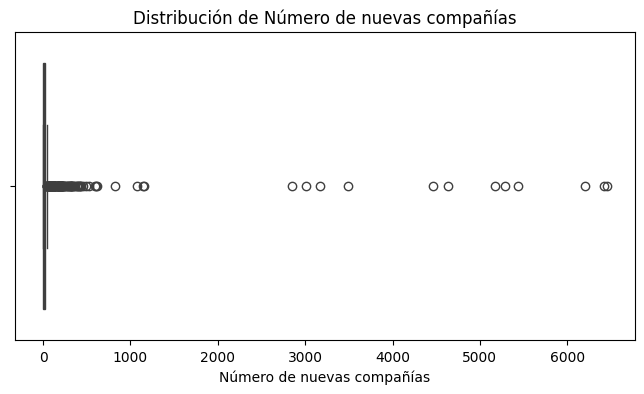

--- Análisis Estadístico: Valor agregado bruto de producción per cápita ---
Q1: 1788.32 | Mediana: 2467.32 | Q3: 3754.46
Media: 4785.16
Outliers detectados: 165 (12.44% del total)
----------------------------------------


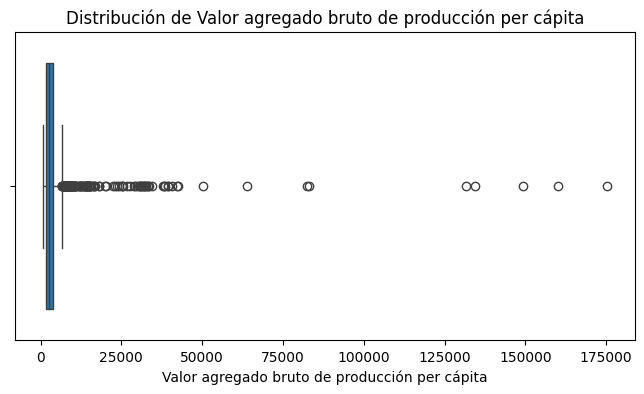

--- Análisis Estadístico: variación interanual real de la producción per cápita ---
Q1: -5.00 | Mediana: 2.67 | Q3: 9.00
Media: 3.26
Outliers detectados: 47 (3.54% del total)
----------------------------------------


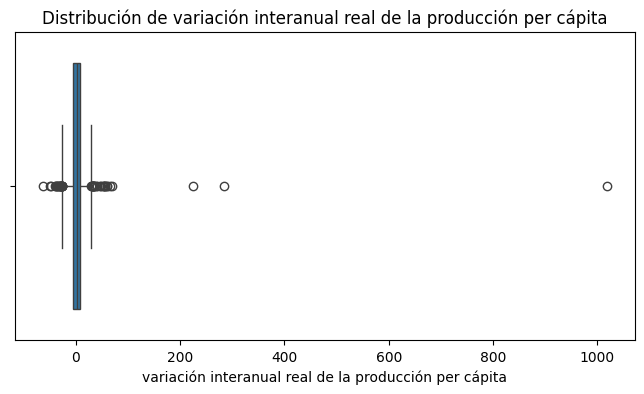

In [26]:
# 1. Identificar columnas numéricas (excluyendo el Año)
cols_numericas = df_limpio.select_dtypes(include=['float64', 'int64']).columns
cols_numericas = [c for c in cols_numericas if c != 'Año']

# Obtenemos el total de registros para el cálculo porcentual
total_registros = len(df_limpio)

# 2. Iterar y generar análisis
for col in cols_numericas:
    # --- Cálculos Estadísticos ---
    q1 = df_limpio[col].quantile(0.25)
    q2 = df_limpio[col].quantile(0.50) # Mediana
    q3 = df_limpio[col].quantile(0.75)
    iqr = q3 - q1
    media = df_limpio[col].mean()

    # Detección de outliers (regla de 1.5 * IQR)
    outliers = df_limpio[(df_limpio[col] < (q1 - 1.5 * iqr)) | (df_limpio[col] > (q3 + 1.5 * iqr))]
    num_outliers = len(outliers)

    # Cálculo del porcentaje
    porcentaje_outliers = (num_outliers / total_registros) * 100

    # --- Impresión de Resultados ---
    print(f"--- Análisis Estadístico: {col} ---")
    print(f"Q1: {q1:.2f} | Mediana: {q2:.2f} | Q3: {q3:.2f}")
    print(f"Media: {media:.2f}")
    print(f"Outliers detectados: {num_outliers} ({porcentaje_outliers:.2f}% del total)")
    print("-" * 40)

    # --- Gráfico ---
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_limpio[col])
    plt.title(f'Distribución de {col}')
    plt.show()

--- Iniciando reporte de cantones con outliers en 'Empleo total registrado' ---

[!] Cantón: Antonio Ante | Outliers detectados: 2
 Año  Empleo total registrado
2019                  5625.17
2021                  4175.50


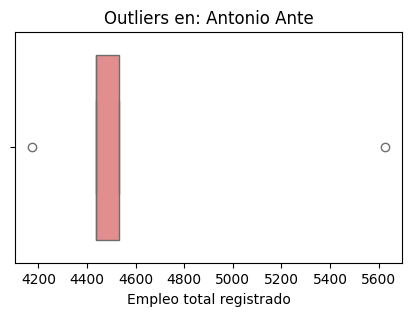


[!] Cantón: San Miguel De Urcuquí | Outliers detectados: 2
 Año  Empleo total registrado
2019                  1997.67
2021                  1315.25


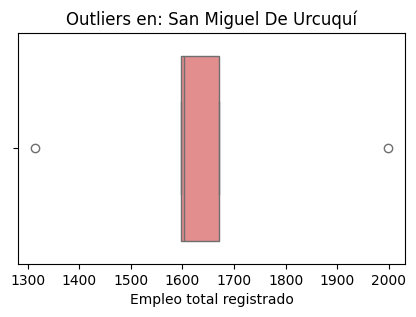


[!] Cantón: Paute | Outliers detectados: 1
 Año  Empleo total registrado
2019                  2856.08


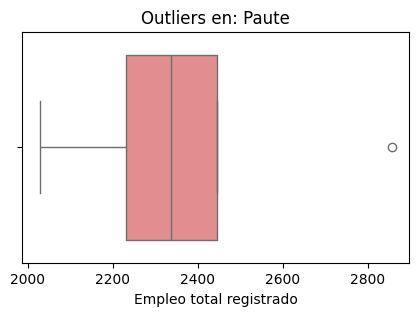


[!] Cantón: Pindal | Outliers detectados: 2
 Año  Empleo total registrado
2019                   290.00
2023                   324.83


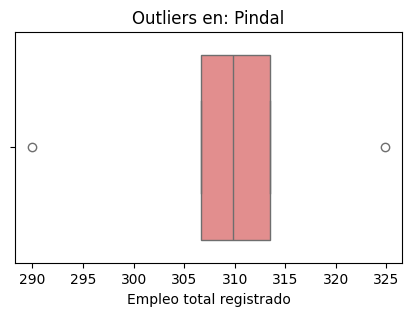


[!] Cantón: Sevilla De Oro | Outliers detectados: 2
 Año  Empleo total registrado
2021                   339.25
2023                   297.17


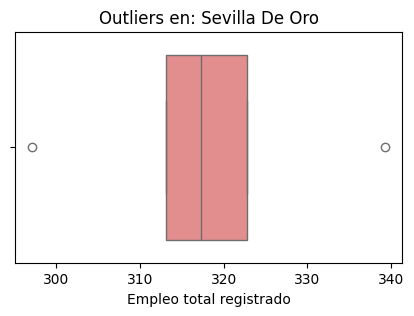


[!] Cantón: Camilo Ponce Enríquez | Outliers detectados: 2
 Año  Empleo total registrado
2020                  7275.67
2022                  7932.83


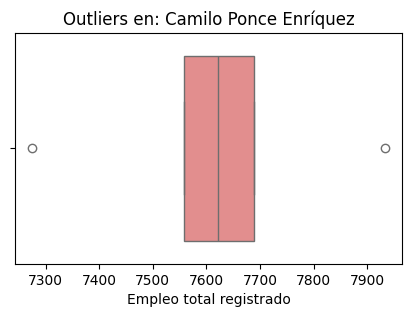


[!] Cantón: Babahoyo | Outliers detectados: 1
 Año  Empleo total registrado
2023                 16678.75


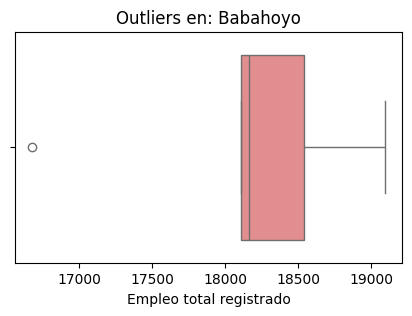


[!] Cantón: Baba | Outliers detectados: 1
 Año  Empleo total registrado
2019                  1932.42


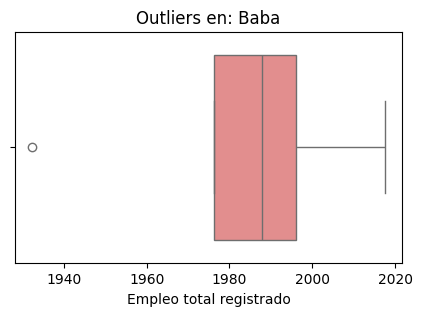


[!] Cantón: Quevedo | Outliers detectados: 1
 Año  Empleo total registrado
2022                 22045.42


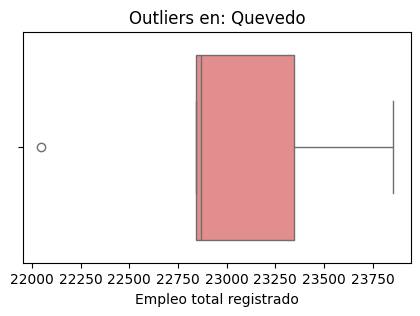


[!] Cantón: Vinces | Outliers detectados: 1
 Año  Empleo total registrado
2021                  3590.75


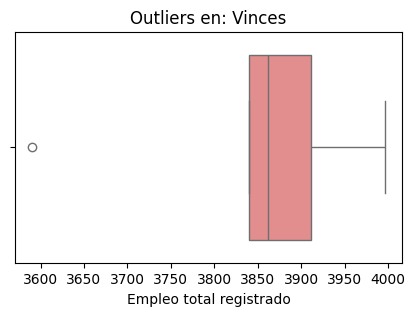


[!] Cantón: Palenque | Outliers detectados: 2
 Año  Empleo total registrado
2019                   327.58
2023                   367.83


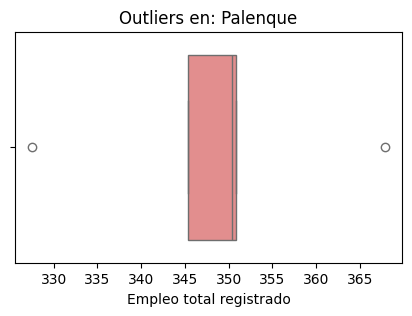


[!] Cantón: Flavio Alfaro | Outliers detectados: 1
 Año  Empleo total registrado
2019                   769.75


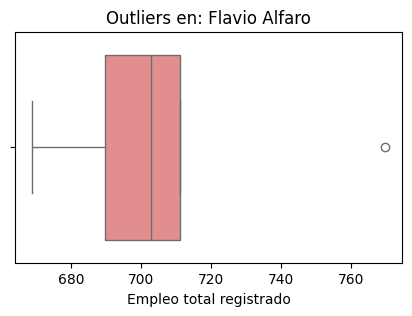


[!] Cantón: Jipijapa | Outliers detectados: 2
 Año  Empleo total registrado
2019                  5068.25
2021                  4620.17


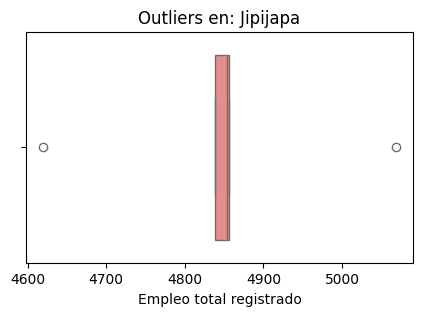


[!] Cantón: Rocafuerte | Outliers detectados: 1
 Año  Empleo total registrado
2023                  1571.25


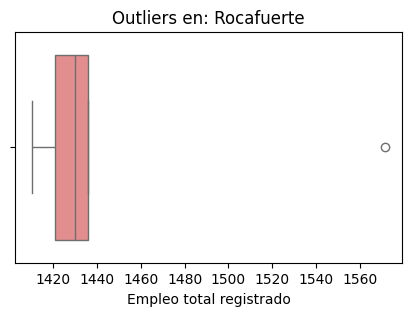


[!] Cantón: Santa Ana | Outliers detectados: 1
 Año  Empleo total registrado
2021                  2854.25


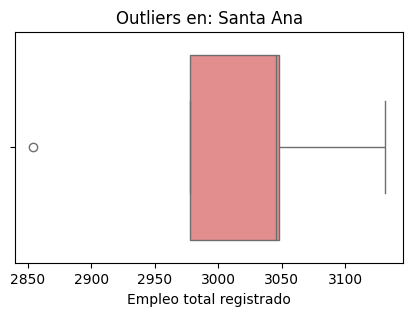


[!] Cantón: Sucre | Outliers detectados: 1
 Año  Empleo total registrado
2023                  5227.25


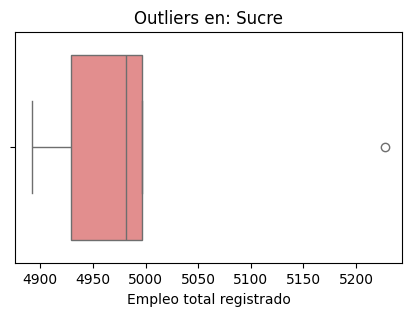


[!] Cantón: Tosagua | Outliers detectados: 1
 Año  Empleo total registrado
2019                  2461.92


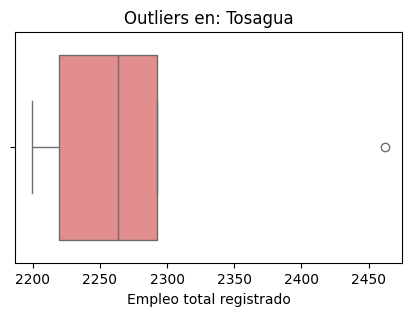


[!] Cantón: Pedernales | Outliers detectados: 2
 Año  Empleo total registrado
2019                  4876.67
2021                  4366.00


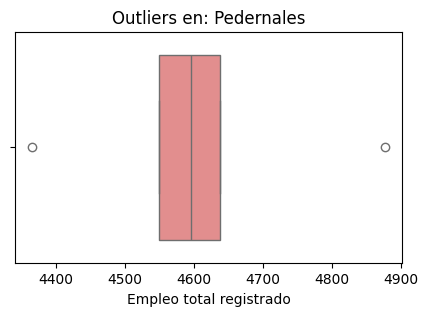


[!] Cantón: Puerto López | Outliers detectados: 1
 Año  Empleo total registrado
2021                   745.25


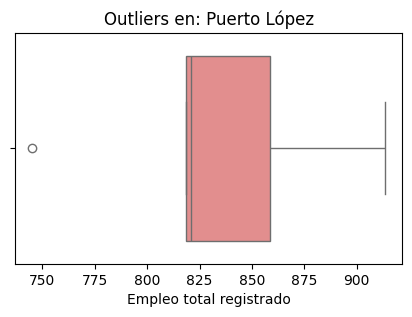


[!] Cantón: Jaramijó | Outliers detectados: 2
 Año  Empleo total registrado
2019                  6303.42
2022                  7093.67


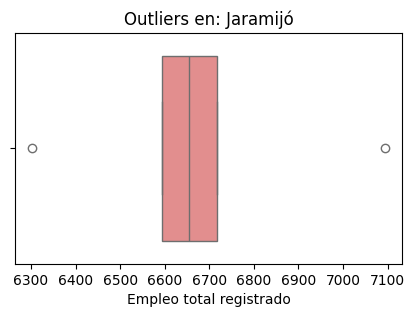


[!] Cantón: Palora | Outliers detectados: 1
 Año  Empleo total registrado
2019                   721.17


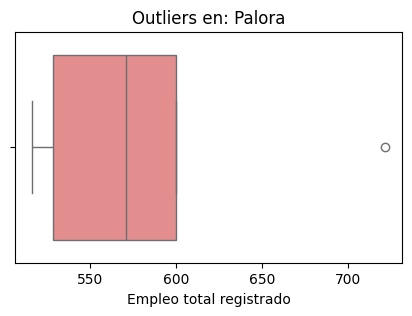


[!] Cantón: Taisha | Outliers detectados: 1
 Año  Empleo total registrado
2023                  1313.33


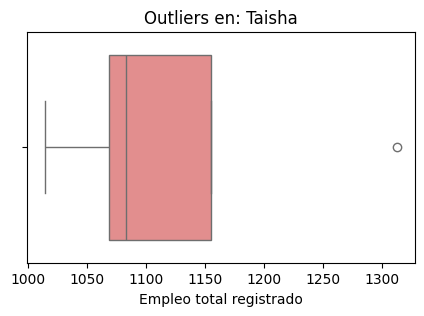


[!] Cantón: Carlos Julio Arosemena Tola | Outliers detectados: 1
 Año  Empleo total registrado
2019                   249.25


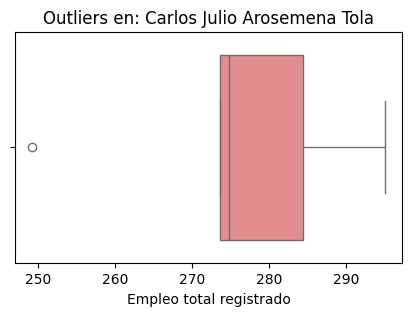


[!] Cantón: Santa Clara | Outliers detectados: 1
 Año  Empleo total registrado
2019                   327.17


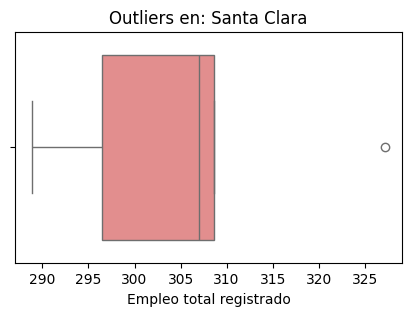


[!] Cantón: Ambato | Outliers detectados: 1
 Año  Empleo total registrado
2019                 69995.08


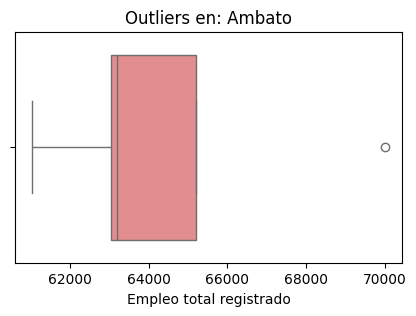


[!] Cantón: Baños De Agua Santa | Outliers detectados: 2
 Año  Empleo total registrado
2019                  4052.08
2021                  3060.08


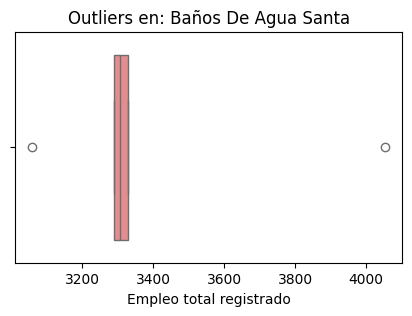


[!] Cantón: Santiago De Píllaro | Outliers detectados: 1
 Año  Empleo total registrado
2019                  2623.25


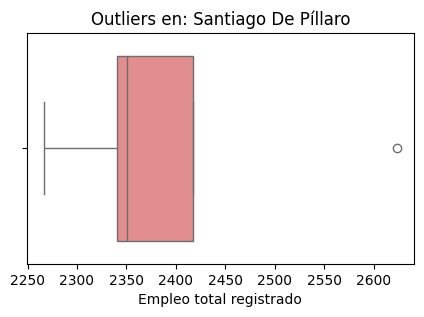


[!] Cantón: Tisaleo | Outliers detectados: 1
 Año  Empleo total registrado
2019                   589.42


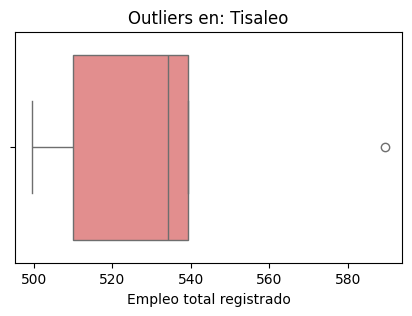


[!] Cantón: Chinchipe | Outliers detectados: 1
 Año  Empleo total registrado
2019                   944.33


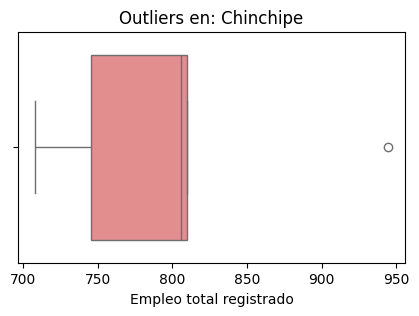


[!] Cantón: Guaranda | Outliers detectados: 1
 Año  Empleo total registrado
2019                  8868.25


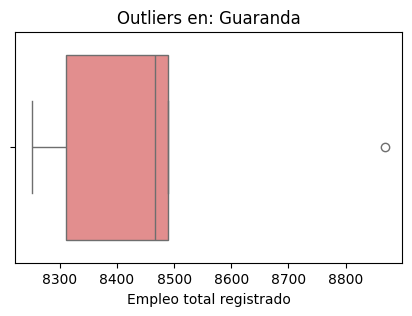


[!] Cantón: Chimbo | Outliers detectados: 1
 Año  Empleo total registrado
2023                   906.67


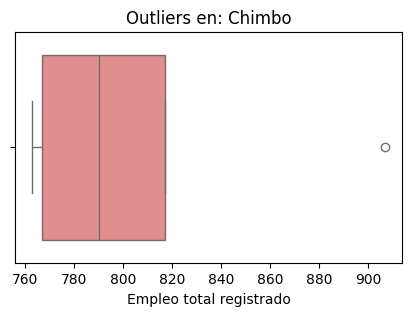


[!] Cantón: Gonzalo Pizarro | Outliers detectados: 2
 Año  Empleo total registrado
2019                   550.42
2021                   381.08


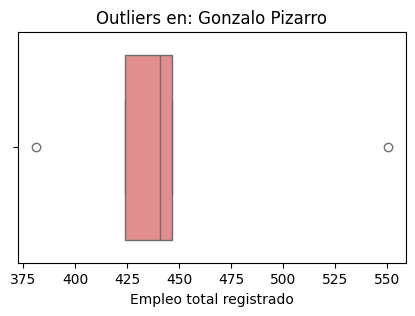


[!] Cantón: La Joya de los Sachas | Outliers detectados: 1
 Año  Empleo total registrado
2023                  4754.75


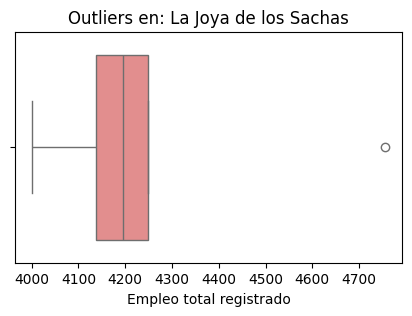


[!] Cantón: La Concordia | Outliers detectados: 1
 Año  Empleo total registrado
2019                  4163.08


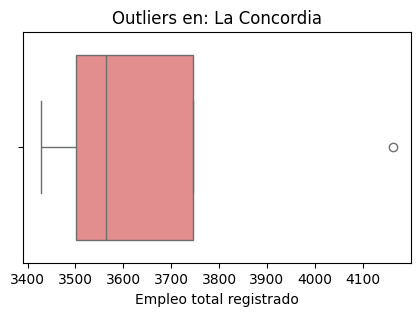


[!] Cantón: Cañar | Outliers detectados: 1
 Año  Empleo total registrado
2021                  4054.25


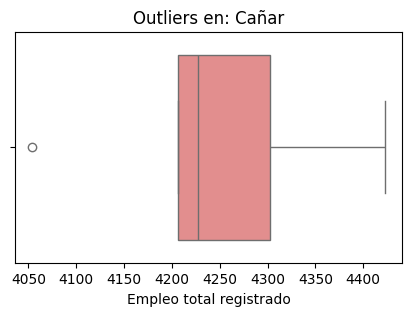


[!] Cantón: Pujilí | Outliers detectados: 1
 Año  Empleo total registrado
2023                  4473.92


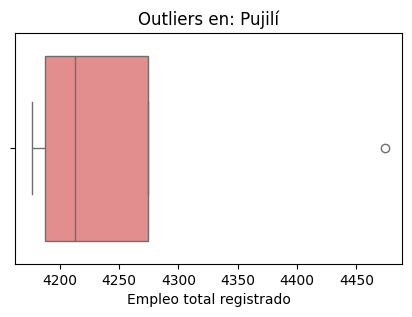


[!] Cantón: Salcedo | Outliers detectados: 1
 Año  Empleo total registrado
2019                   6318.0


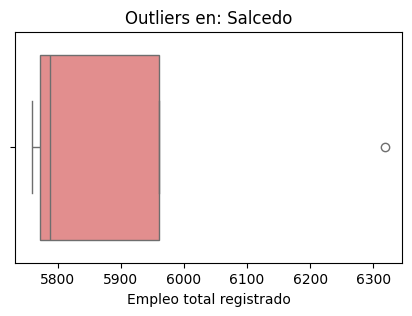


[!] Cantón: Colta | Outliers detectados: 2
 Año  Empleo total registrado
2019                  2126.33
2021                  1950.25


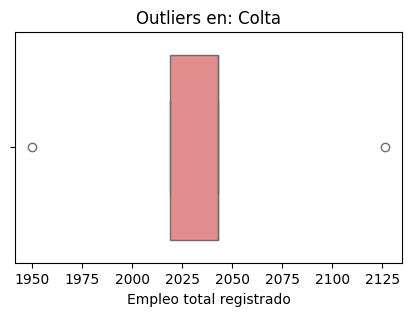


[!] Cantón: Pallatanga | Outliers detectados: 1
 Año  Empleo total registrado
2021                   810.58


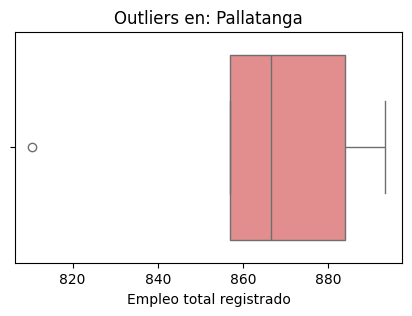


[!] Cantón: Atahualpa | Outliers detectados: 1
 Año  Empleo total registrado
2019                    303.5


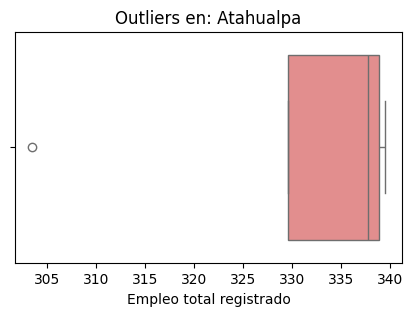


[!] Cantón: Chilla | Outliers detectados: 1
 Año  Empleo total registrado
2019                   119.17


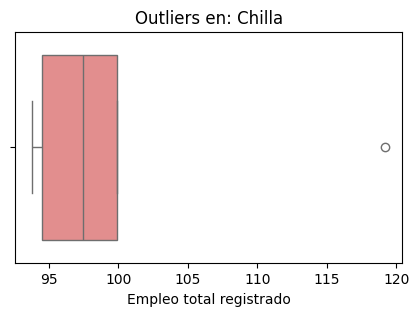


[!] Cantón: Pasaje | Outliers detectados: 1
 Año  Empleo total registrado
2019                   9869.0


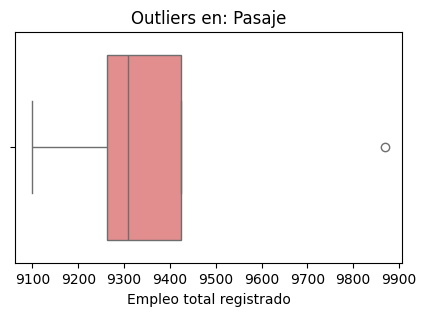


[!] Cantón: Esmeraldas | Outliers detectados: 1
 Año  Empleo total registrado
2019                 21569.17


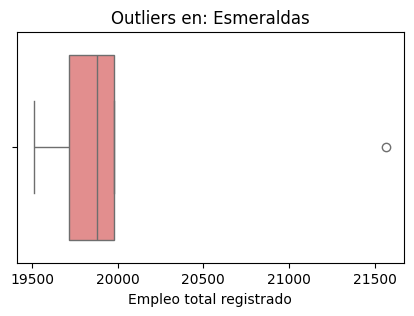


[!] Cantón: Quinindé | Outliers detectados: 1
 Año  Empleo total registrado
2019                  7077.33


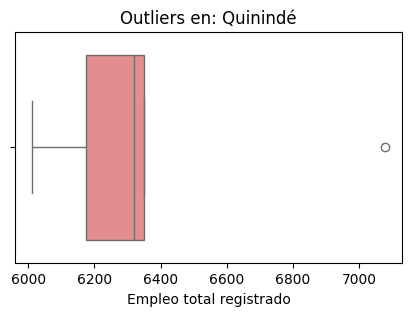


[!] Cantón: Atacames | Outliers detectados: 2
 Año  Empleo total registrado
2019                  4211.75
2021                  3509.00


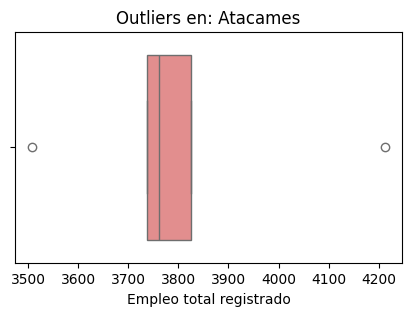


[!] Cantón: Colimes | Outliers detectados: 2
 Año  Empleo total registrado
2019                   447.17
2023                   376.58


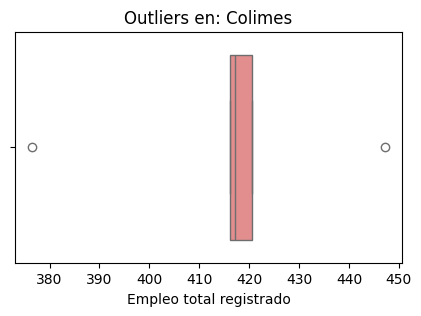


[!] Cantón: Palestina | Outliers detectados: 1
 Año  Empleo total registrado
2019                   461.42


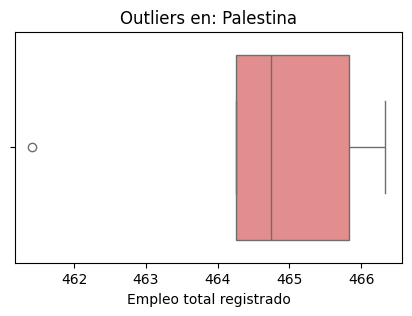


[!] Cantón: Pedro Carbo | Outliers detectados: 1
 Año  Empleo total registrado
2023                  2232.67


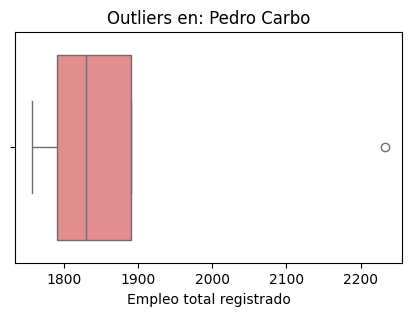


[!] Cantón: Playas | Outliers detectados: 2
 Año  Empleo total registrado
2019                  3184.83
2022                  2714.42


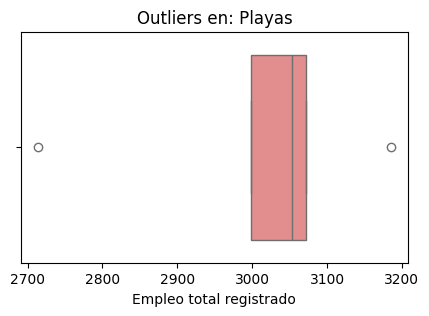


[!] Cantón: Coronel Marcelino Maridueña | Outliers detectados: 2
 Año  Empleo total registrado
2019                  5095.67
2023                  4628.33


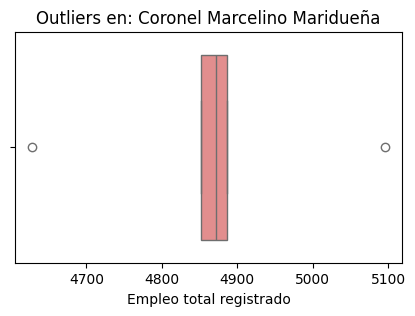


[!] Cantón: Lomas De Sargentillo | Outliers detectados: 2
 Año  Empleo total registrado
2020                   755.58
2023                   515.08


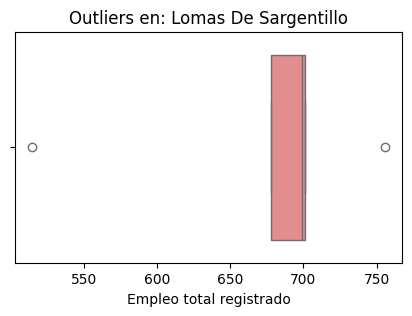


--- Proceso finalizado ---


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

lista_cantones = df_limpio['Cantón'].unique()
columna = 'Empleo total registrado'

print(f"--- Iniciando reporte de cantones con outliers en '{columna}' ---")

for canton in lista_cantones:
    # Filtrar datos por cantón y periodo
    df_temp = df_limpio[(df_limpio['Cantón'] == canton) &
                        (df_limpio['Año'] >= 2019) &
                        (df_limpio['Año'] <= 2023)].copy()

    # Calcular límites
    Q1 = df_temp[columna].quantile(0.25)
    Q3 = df_temp[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Identificar outliers
    outliers = df_temp[(df_temp[columna] < limite_inferior) | (df_temp[columna] > limite_superior)]
    num_outliers = len(outliers)

    # Solo imprimimos y graficamos si encontramos al menos un outlier
    if num_outliers > 0:
        print(f"\n[!] Cantón: {canton} | Outliers detectados: {num_outliers}")
        # Imprimir detalles de los años y valores
        print(outliers[['Año', columna]].to_string(index=False))

        # Gráfico
        plt.figure(figsize=(5, 3))
        sns.boxplot(x=df_temp[columna], color='lightcoral')
        plt.title(f'Outliers en: {canton}')
        plt.show()

print("\n--- Proceso finalizado ---")

La eliminación de valores atípicos genuinos puede sesgar gravemente los estimadores, ya que estos puntos contienen información crítica sobre el comportamiento del sistema bajo condiciones no ordinarias. Un modelo que ignora los periodos de crisis es un modelo que falla en capturar la complejidad de la realidad económica.”

Bajo este criterio, se ha determinado que los outliers identificados son observaciones de alta relevancia informativa, pues permiten al modelo de predicción aprender de la volatilidad histórica del mercado laboral. Por tanto, en lugar de proceder a su eliminación —lo cual reduciría la representatividad geográfica y temporal de la muestra—, se optó por conservar estas observaciones.

## 5. Gráficos bivariados y análisis de correlación

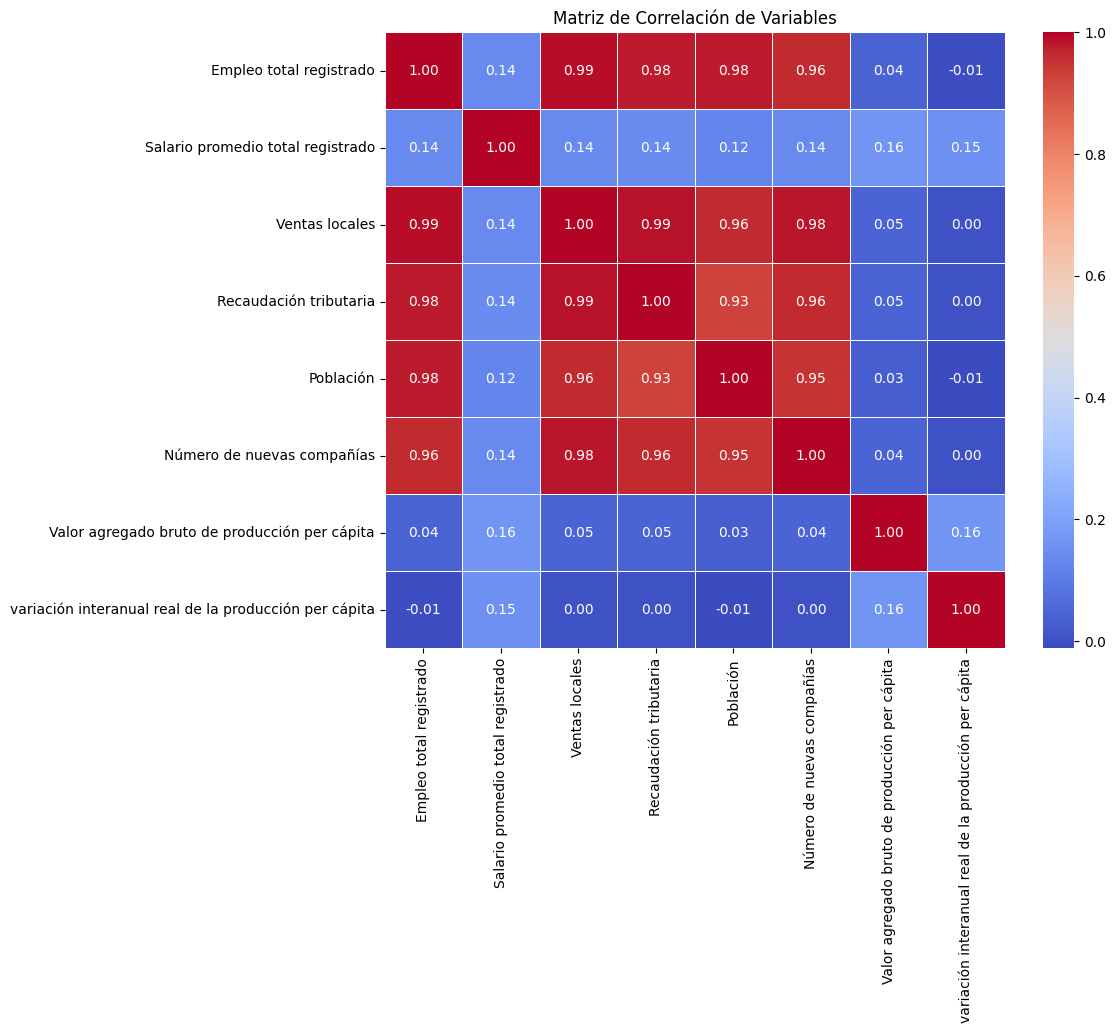

In [28]:
# Seleccionamos solo las columnas numéricas
df_num = df_limpio.select_dtypes(include=['float64', 'int64']).drop(columns=['Año'], errors='ignore')

# Calculamos la matriz de correlación (usamos 'pearson' por defecto)
corr_matrix = df_num.corr()

# Generamos el Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables')
plt.show()

Tras el análisis exploratorio realizado mediante la **matriz de correlación**, se identificó un nivel de multicolinealidad severa entre las variables representativas de la capacidad económica (empleo, ventas, recaudación y número de empresas), con **coeficientes de correlación superiores a 0.90**. Según Gujarati y Porter (2009) en su obra `Basic econometrics`, la **presencia de colinealidad perfecta o cuasi-perfecta en modelos de regresión conduce a estimadores inestables y a la inflación de los errores estándar, lo que compromete la significancia estadística de los predictores individuales.**

Para mitigar esta problemática, se procedió a una reestructuración de la base de datos bajo dos criterios técnicos. Primero, se aplicará un Análisis de Componentes Principales (PCA) sobre el conjunto de variables altamente correlacionadas para consolidarlas en un **índice sintético de capacidad económica**; este procedimiento es respaldado por Jolliffe (2002) en su obra `Principal component analysis`, quien establece que el **PCA es la herramienta idónea para reducir la dimensionalidad y eliminar la redundancia informativa, reteniendo simultáneamente la varianza estructural del sistema**.

Segundo, se adoptó una estrategia de segmentación de variables: **se integró el logaritmo natural de la población como variable independiente para estabilizar su varianza y linealizar su efecto**, práctica estandarizada en econometría para corregir la heterocedasticidad según Wooldridge (2016), y se conservó de forma independiente la variación interanual real de la producción per cápita. Esta última se seleccionó como el **indicador primario de dinamismo económico **, capacidad de una economía (en este caso, un cantón) para adaptarse, crecer y generar riqueza de forma constante a lo largo del tiempo, debido a su alta correlación con el** Valor Agregado Bruto (VAB)**, permitiendo así capturar el crecimiento real sin incurrir en redundancias con el índice sintético creado. Esta arquitectura metodológica asegura que cada variable introducida en el modelo aporte información ortogonal, optimizando la capacidad predictiva y la interpretabilidad del sistema ante los objetivos del presente estudio.

### 1. Log-Población

In [30]:
# 1. Creamos la nueva columna con el logaritmo natural (ln) de la población
# Usamos log1p (log(1+x)) por precaución, por si hubiera algún valor de 0
df_limpio['Log_Poblacion'] = np.log1p(df_limpio['Población'])

# 2. Eliminamos la columna original 'Población'
df_limpio = df_limpio.drop(columns=['Población'])

# Verificación rápida
print(df_limpio[['Log_Poblacion']].head())
print(f"Columnas actuales: {df_limpio.columns.tolist()}")

   Log_Poblacion
0      12.285073
1      12.297119
2      12.307198
3      12.317372
4      12.328162
Columnas actuales: ['Año', 'Cantón', 'Provincia', 'Empleo total registrado', 'Salario promedio total registrado', 'Ventas locales', 'Recaudación tributaria', 'Número de nuevas compañías', 'Valor agregado bruto de producción per cápita', 'variación interanual real de la producción per cápita', 'Log_Poblacion']


### 2. PCA indicador sintético de capacidad económica

In [33]:
# 1. Definir las variables que componen la 'Capacidad Económica'
cols_capacidad = [
    'Empleo total registrado',
    'Salario promedio total registrado',
    'Ventas locales',
    'Recaudación tributaria',
    'Número de nuevas compañías'
]

# 2. Escalar los datos (Media=0, Desviación=1)
scaler = StandardScaler()
X_capacidad_scaled = scaler.fit_transform(df_limpio[cols_capacidad])

# 3. Aplicar PCA (Reducir a 1 solo componente principal)
pca = PCA(n_components=1)
indice_pca = pca.fit_transform(X_capacidad_scaled)

# 4. Asignar el resultado al DataFrame
# Usamos el primer componente (índice 0)
df_limpio['Indice_Capacidad_Economica'] = indice_pca

# 5. Imprimir la importancia de la varianza explicada
print(f"Varianza explicada por el índice: {pca.explained_variance_ratio_[0]:.2%}")

df_limpio.info()

Varianza explicada por el índice: 79.16%
<class 'pandas.core.frame.DataFrame'>
Index: 1326 entries, 0 to 1333
Data columns (total 12 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Año                                                    1326 non-null   int64  
 1   Cantón                                                 1326 non-null   object 
 2   Provincia                                              1326 non-null   object 
 3   Empleo total registrado                                1326 non-null   float64
 4   Salario promedio total registrado                      1326 non-null   float64
 5   Ventas locales                                         1326 non-null   float64
 6   Recaudación tributaria                                 1326 non-null   float64
 7   Número de nuevas compañías                             1326 non-null   float64
 8   Valor agrega

Coeficiente de correlación entre Log_Poblacion e Indice_Capacidad_Economica: 0.4287


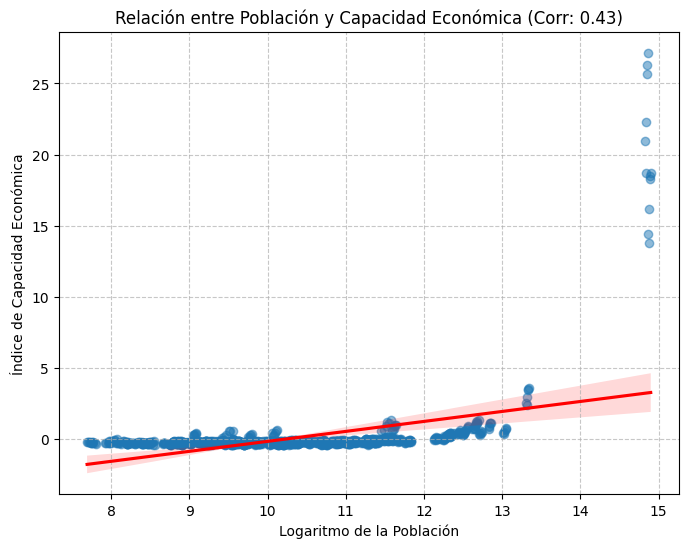

In [35]:
# Se analiza la correlación de log poblacion con el índice sintético
# para analizar si existe correlación que empobrezca los modelos a construir.
# 1. Calcular el coeficiente de correlación de Pearson
correlacion = df_limpio['Log_Poblacion'].corr(df_limpio['Indice_Capacidad_Economica'])
print(f"Coeficiente de correlación entre Log_Poblacion e Indice_Capacidad_Economica: {correlacion:.4f}")

# 2. Gráfico de dispersión con línea de tendencia
plt.figure(figsize=(8, 6))
sns.regplot(x='Log_Poblacion', y='Indice_Capacidad_Economica', data=df_limpio,
            scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.title(f'Relación entre Población y Capacidad Económica (Corr: {correlacion:.2f})')
plt.xlabel('Logaritmo de la Población')
plt.ylabel('Índice de Capacidad Económica')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Una vez finalizada la limpieza de datos el dataset final es:

In [39]:
# 1. Definir la lista de columnas que deseas conservar
columnas_seleccionadas = [
    'Año',
    'Cantón',
    'variación interanual real de la producción per cápita',
    'Log_Poblacion',
    'Indice_Capacidad_Economica'
]

# 2. Crear el nuevo DataFrame filtrado
df_final = df_limpio[columnas_seleccionadas].copy()

# 3. Guardar en formato CSV para tu anexo de datos
df_final.to_csv('df_final_procesado.csv', index=False)

# 4. Verificación final
print("El DataFrame ha sido guardado exitosamente.")
print(df_final.head(10))

El DataFrame ha sido guardado exitosamente.
    Año        Cantón  variación interanual real de la producción per cápita  \
0  2019        Ibarra                                              -1.58       
1  2020        Ibarra                                             -16.87       
2  2021        Ibarra                                               1.90       
3  2022        Ibarra                                              10.43       
4  2023        Ibarra                                               6.72       
5  2024        Ibarra                                              13.00       
6  2019  Antonio Ante                                               0.91       
7  2020  Antonio Ante                                             -19.05       
8  2021  Antonio Ante                                             -15.61       
9  2022  Antonio Ante                                               5.43       

   Log_Poblacion  Indice_Capacidad_Economica  
0      12.285073            

## 6. Feature Engineering

In [40]:
# 1. Invertimos la escala (esto convierte 'capacidad' en 'vulnerabilidad')
# Multiplicamos por -1 para que valores altos signifiquen mayor riesgo
df_final['Indice_Riesgo_Socioeconomico'] = df_final['Indice_Capacidad_Economica'] * -1

# 2. Normalizamos entre 0 y 1 para que sea un indicador interpretable
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_final['Indice_Riesgo_Socioeconomico'] = scaler.fit_transform(df_final[['Indice_Riesgo_Socioeconomico']])

In [41]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1326 entries, 0 to 1333
Data columns (total 6 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Año                                                    1326 non-null   int64  
 1   Cantón                                                 1326 non-null   object 
 2   variación interanual real de la producción per cápita  1326 non-null   float64
 3   Log_Poblacion                                          1326 non-null   float64
 4   Indice_Capacidad_Economica                             1326 non-null   float64
 5   Indice_Riesgo_Socioeconomico                           1326 non-null   float64
dtypes: float64(4), int64(1), object(1)
memory usage: 72.5+ KB


Para la estimación del **Índice de Pobreza**, se adoptó un enfoque de normalización inversa sobre el componente sintético de capacidad económica. Dado que la teoría de la economía del desarrollo postula una relación negativa entre el dinamismo productivo y la incidencia de la pobreza (Sen, 1999), se procedió a la inversión de la polaridad del Índice de Capacidad Económica. Posteriormente, se aplicó una normalización de rango [0,1] para transformar el resultado en un **Índice de Riesgo Socioeconómico (IRS)**. Este indicador permite cuantificar la probabilidad de pobreza estructural en cada cantón, ofreciendo una métrica estandarizada y comparable a nivel nacional, la cual sirve como proxy ante la ausencia de mediciones censales directas para el periodo de estudio.

# 3. Load the data

Debido a que no se esta usando un gestor de base de datos para este proyecto lo que se realizará es guardar el dataset limpio para el futuro modelo a realizarse

In [42]:
# Eliminar la columna del DataFrame
df_final = df_final.drop(columns=['Indice_Capacidad_Economica'])

# Guardar nuevamente el archivo actualizado
df_final.to_csv('df_final_procesado.csv', index=False)

# Verificar columnas restantes
print("Columnas actuales en df_final:")
print(df_final.columns.tolist())

Columnas actuales en df_final:
['Año', 'Cantón', 'variación interanual real de la producción per cápita', 'Log_Poblacion', 'Indice_Riesgo_Socioeconomico']


In [43]:
# Guardar el DataFrame como archivo Excel (.xlsx)
df_final.to_excel('df_final_procesado.xlsx', index=False)

print("El archivo 'df_final_procesado.xlsx' ha sido guardado exitosamente.")

El archivo 'df_final_procesado.xlsx' ha sido guardado exitosamente.


# Referencias Bibliográficas



*   Gujarati, D. N., & Porter, D. C. (2009). Basic econometrics (5ta ed.). McGraw-Hill Education.

* Jolliffe, I. T. (2002). Principal component analysis (2da ed.). Springer-Verlag.

* Wooldridge, J. M. (2016). Introductory econometrics: A modern approach (6ta ed.). Cengage Learning.
